# Irembo Document Authentication AI: Champion Pipeline
This notebook implements a state-of-the-art document verification system for the Irembo platform. It uses transfer learning with **EfficientNetB0** to detect sophisticated forgeries in Rwandan governmental documents.

### 🚀 Pipeline Overview:
1. **Config & Environment Setup**: Optimized hyperparameters.
2. **Standardized Preprocessing**: Built-in EfficientNet scaling.
3. **Stage 1 (Forensic Foundation)**: Pre-training on CASIA 2.0.
4. **Stage 2 (Local Context Fine-Tuning)**: Specializing in Rwandan ID forgery patterns.
5. **Advanced Evaluation**: Confusion Matrix and ROC Analysis.


## 1. Environment Setup & Dependencies

### 1.1. Core Imports & GPU Verification
We import TensorFlow for the deep learning engine, and standard data science tools for analysis.

In [1]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import PIL
from PIL import Image
import json

# Setup Environment
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TF warnings

print(f"✅ TensorFlow Version: {tf.__version__}")
print(f"✅ GPU Status: {'Available' if len(tf.config.list_physical_devices('GPU')) > 0 else 'Not Found (Using CPU)'}")


✅ TensorFlow Version: 2.20.0
✅ GPU Status: Not Found (Using CPU)


In [15]:
# ⚙️ DATA POPULATION: Generate 6000 Rwandan Documents
# Skip this if you already ran the script in the terminal.
from synthetic_document_generator import RwandanDocumentGenerator

populator = RwandanDocumentGenerator(output_dir='synthetic_documents')
print("🔄 Refreshing dataset with 6000 images (to hit 70%+ accuracy)...")
populator.generate_dataset(num_samples_per_type=1500, noise_levels=['medium', 'high'])
print("✅ Dataset refreshed. You can now proceed to training.")

🔄 Refreshing dataset with 6000 images (to hit 70%+ accuracy)...
✅ Dataset refreshed. You can now proceed to training.


In [20]:
import mysql.connector
import os
import random
import json
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

# EMBEDDED GENERATOR TO BYPASS CACHING
class HighRiskGenerator:
    def __init__(self, output_dir='high_risk_dataset'):
        self.output_dir = Path(output_dir)
        self.doc_types = [
            'salary_slip', 'bank_statement', 'employment_contract',
            'court_judgment', 'certificate_of_celibacy', 'criminal_record_clearance',
            'academic_transcript', 'notarial_act', 'power_of_attorney'
        ]
        for dt in self.doc_types:
            (self.output_dir / dt / 'valid').mkdir(parents=True, exist_ok=True)
            (self.output_dir / dt / 'invalid').mkdir(parents=True, exist_ok=True)

    def generate(self, name, nid, is_valid=True):
        img = Image.new('RGB', (224, 224), color=(245, 245, 245))
        draw = ImageDraw.Draw(img)
        dt = random.choice(self.doc_types)
        draw.text((10, 10), f"GOV RWANDA: {dt.upper()}", fill=(0,0,0))
        draw.text((10, 40), f"Name: {name}", fill=(0,0,0))
        draw.text((10, 60), f"NID: {nid}", fill=(0,0,0))
        if not is_valid:
            draw.text((50, 50), "TAMPERED", fill=(255,0,0))
        
        status = 'valid' if is_valid else 'invalid'
        fname = f"{dt}_{nid}_{random.randint(100,999)}.jpg"
        img.save(self.output_dir / dt / status / fname)

# Fetch from MySQL
try:
    db = mysql.connector.connect(host="localhost", user="root", password="", database="iremboaipowered")
    cursor = db.cursor(dictionary=True)
    cursor.execute("SELECT first_name, last_name, national_id FROM citizensregistry")
    records = cursor.fetchall()
    db.close()

    gen = HighRiskGenerator()
    print(f"🚀 Generating High-Risk Dataset for {len(records)} identities...")
    for r in records:
        full_name = f"{r['first_name']} {r['last_name']}"
        for _ in range(10):
            gen.generate(full_name, r['national_id'], is_valid=True)
            gen.generate(full_name, r['national_id'], is_valid=False)
    print("✅ High-Risk Dataset generated in 'high_risk_dataset/'")

except Exception as e:
    print(f"❌ Error: {e}")


🚀 Generating High-Risk Dataset for 110 identities...
✅ High-Risk Dataset generated in 'high_risk_dataset/'


### 1.2. Global Hyperparameters & Project Configuration
Centralized configuration class for easy model tuning.

In [3]:
from pathlib import Path
import os

class Config:
    # 🎯 Optimized Hyperparameters for Higher Accuracy
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    LEARNING_RATE_STAGE_1 = 5e-4
    LEARNING_RATE_STAGE_2 = 2e-5
    EPOCHS_STAGE_1 = 20
    EPOCHS_STAGE_2 = 40
    DROPOUT_RATE = 0.5
    
    # 📂 Local Paths
    BASE_DIR = Path(r"C:\xampp\htdocs\aipowered")
    CASIA_PATH = BASE_DIR / "CASIA2"
    CASIA_AUTH = CASIA_PATH / "Au"
    CASIA_TAMP = CASIA_PATH / "Tp"
    
    # 🇷🇼 HIGH-RISK DATASET (Refined Categories)
    RWANDAN_SYNTHETIC = BASE_DIR / "high_risk_dataset"
    RWANDAN_SAMPLE = BASE_DIR / "samples_documents"
    
    MODEL_SAVE_PATH = BASE_DIR / "output" / "models" / "auth_check_model.keras"

# Ensure dirs exist
os.makedirs(os.path.dirname(Config.MODEL_SAVE_PATH), exist_ok=True)
print(f" Config updated for HIGH-RISK Dataset: {Config.RWANDAN_SYNTHETIC}")


 Config updated for HIGH-RISK Dataset: C:\xampp\htdocs\aipowered\high_risk_dataset


### 1.3. CASIA 2.0 Dataset Loading & Splitting
Building the forensic DataFrame from generic forgery datasets (CASIA v2.0).

In [4]:
def load_casia_dataframe(auth_path, tamp_path):
    """Scan and build the CASIA 2.0 forgery dataset by looking into subfolders."""
    images, labels = [], []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.bmp')
    
    # helper to walk through folders
    def collect_images(root_path, label_val):
        if not root_path.exists():
            print(f"⚠️ Warning: Path not found: {root_path}")
            return
        
        count = 0
        # Use rglob for recursive scanning of all subfolders
        for img in root_path.rglob("*"):
            if img.suffix.lower() in valid_extensions:
                images.append(str(img))
                labels.append(label_val)
                count += 1
        print(f"✅ Found {count} images in {root_path.name}")

    # Authentic (0)
    collect_images(auth_path, 0)
    
    # Tampered (1)
    collect_images(tamp_path, 1)
                
    if not images:
        print("❌ CRITICAL: CASIA Dataset not found in paths. Check your BASE_DIR and folder structure.")
        return pd.DataFrame({'filename': [], 'label': []})
                
    df = pd.DataFrame({'filename': images, 'label': labels})
    df['label'] = df['label'].astype(str) # For flow_from_dataframe
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

# Main DF Loading & Splitting
df_casia = load_casia_dataframe(Config.CASIA_AUTH, Config.CASIA_TAMP)
print(f"📊 Dataset Info: Total {len(df_casia)} | Auth: {len(df_casia[df_casia['label']=='0'])} | Tamp: {len(df_casia[df_casia['label']=='1'])}")

if not df_casia.empty:
    train_df, test_df = train_test_split(df_casia, test_size=0.2, random_state=42, stratify=df_casia['label'])
    train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])
    print(f"✅ Split Check: Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
else:
    print("⚠️ Skipping Stage 1 Split (Empty CASIA). We will proceed directly to High-Risk Stage 2.")
    # Initialize empty frames to avoid NameErrors later
    train_df = val_df = test_df = pd.DataFrame(columns=['filename', 'label'])


✅ Found 7491 images in Au
✅ Found 5123 images in Tp
📊 Dataset Info: Total 12614 | Auth: 7491 | Tamp: 5123
✅ Split Check: Train 8072 | Val 2019 | Test 2523


In [5]:
def load_rwandan_dataframe(synthetic_path, sample_path):
    """Scan and build the Rwandan document dataset from High-Risk categories."""
    images, labels = [], []
    
    # 1. Scan Synthetic High-Risk Documents
    if synthetic_path.exists():
        doc_categories = [
            'salary_slip', 'bank_statement', 'employment_contract',
            'court_judgment', 'certificate_of_celibacy', 'criminal_record_clearance',
            'academic_transcript', 'notarial_act', 'power_of_attorney'
        ]
        for doc_type in doc_categories:
            for status in ['valid', 'invalid']:
                folder = synthetic_path / doc_type / status
                if folder.exists():
                    for img in folder.glob("*.jpg"):
                        images.append(str(img))
                        # 1 = Authentic/Valid, 0 = Tampered/Invalid
                        labels.append(1 if status == 'valid' else 0)
    
    # 2. Scan Sample Documents (Real ones)
    if sample_path.exists():
        for status in ['valid', 'invalid']:
            folder = sample_path / status
            if folder.exists():
                for img in folder.glob("*.*"):
                    if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                        images.append(str(img))
                        labels.append(1 if status == 'valid' else 0)
                
    df = pd.DataFrame({'filename': images, 'label': labels})
    df['label'] = df['label'].astype(str)
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

# Load the Local Rwandan Dataset (High-Risk Categories)
df_rwanda = load_rwandan_dataframe(Config.RWANDAN_SYNTHETIC, Config.RWANDAN_SAMPLE)
print(f"🇷🇼 Rwandan HIGH-RISK Dataset Loaded: {len(df_rwanda)} images")
print(f"📊 Composition: Authentic: {len(df_rwanda[df_rwanda['label']=='1'])} | Tampered: {len(df_rwanda[df_rwanda['label']=='0'])}")

# High-Risk Split
rw_train, rw_test = train_test_split(df_rwanda, test_size=0.15, random_state=42, stratify=df_rwanda['label'])
rw_train, rw_val = train_test_split(rw_train, test_size=0.15, random_state=42, stratify=rw_train['label'])

print(f"✅ High-Risk Split: Train {len(rw_train)} | Val {len(rw_val)} | Test {len(rw_test)}")


🇷🇼 Rwandan HIGH-RISK Dataset Loaded: 4393 images
📊 Composition: Authentic: 2198 | Tampered: 2195
✅ High-Risk Split: Train 3173 | Val 561 | Test 659


### 1.4. Real-time Data Augmentation & Generators
Preprocessing via `ImageDataGenerator` optimized for EfficientNet (manual 1./255 rescaling disabled).

In [6]:
# ⚙️ Data Augmentation & Generators
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=effnet_preprocess
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess
)

# Only build CASIA generators if data exists
if not train_df.empty:
    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=True
    )
    val_generator = val_test_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
    test_generator = val_test_datagen.flow_from_dataframe(
        test_df, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
    )
else:
    print("⚠️ Skipping CASIA Generators - No data available.")
    # Placeholders to prevent compilation errors later if referenced
    train_generator = None

print("✅ Generators configuration handled.")


Found 8072 validated image filenames belonging to 2 classes.
Found 2019 validated image filenames belonging to 2 classes.
Found 2523 validated image filenames belonging to 2 classes.
✅ Generators configuration handled.


## 2. Model Architecture: Enhanced EfficientNetB0 (ULTRA ACCURACY)
Building the Production-Grade CNN with Dual-Head Pooling (Avg + Max).

In [7]:
# 🏗️ Champion Model Architecture: EfficientNetB0 (ULTRA ACCURACY)
def build_tampering_detection_model(learning_rate):
    """
    Constructs an enhanced transfer learning architecture.
    Features: Multi-head pooling (Avg + Max) to capture both overall noise and peak forgery artifacts.
    """
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*Config.IMG_SIZE, 3))
    base_model.trainable = False # Initial freeze
    
    # --- Advanced Head ---
    avg_pool = layers.GlobalAveragePooling2D()(base_model.output)
    max_pool = layers.GlobalMaxPooling2D()(base_model.output)
    merged = layers.Concatenate()([avg_pool, max_pool])
    
    x = layers.BatchNormalization()(merged)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(Config.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer='l2')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs, name="Irembo_AuthCheck_Ultra")
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Create Model
model = build_tampering_detection_model(Config.LEARNING_RATE_STAGE_1)

# Only calculate class weights if CASIA data exists
if not train_df.empty:
    class_weights = class_weight.compute_class_weight(
        'balanced', classes=np.unique(train_df['label']), y=train_df['label']
    )
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    print(f"✅ Enhanced Model Initialized | Class Weights: {class_weight_dict}")
else:
    class_weight_dict = None
    print("✅ Model Initialized (No Stage 1 Weights needed).")


✅ Enhanced Model Initialized | Class Weights: {0: np.float64(0.8418856904463913), 1: np.float64(1.2312385600976206)}


## 3. Training Stage 1: Forensic Foundation (CASIA Training)
Establishing the model's ability to spot digital manipulation artifacts.

In [39]:
# 🚀 STAGE 1: Forensic Foundation (CASIA Training)
if train_generator and not train_df.empty:
    checkpoint_cb = callbacks.ModelCheckpoint(
        str(Config.BASE_DIR / "output" / "models" / "checkpoint_best.keras"),
        save_best_only=True, monitor='val_auc', mode='max'
    )
    early_stopping_cb = callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor='val_loss', mode='min'
    )
    reduce_lr_cb = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1
    )

    print("\n STARTING STAGE 1: Foundation Building (CASIA)...")
    # Quick Training (Reduced Epochs for MVP)
    history_stage1 = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=3, # Stage 1 Training (MVP)
        class_weight=class_weight_dict,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=1
    )
else:
    print("⚠️ SKIPPING STAGE 1 TRAINING - CASIA dataset is missing.")
    print("AI will proceed to Stage 2 training using ONLY High-Risk Rwandan data.")



 STARTING STAGE 1: Foundation Building (CASIA)...
Epoch 1/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 993s 4s/step - accuracy: 0.6943 - auc: 0.7652 - loss: 0.9181 - val_accuracy: 0.6662 - val_auc: 0.7687 - val_loss: 0.8632 - learning_rate: 5.0000e-04
Epoch 2/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 1256s 5s/step - accuracy: 0.7092 - auc: 0.7807 - loss: 0.7554 - val_accuracy: 0.7003 - val_auc: 0.7729 - val_loss: 0.7116 - learning_rate: 5.0000e-04
Epoch 3/3
253/253 ━━━━━━━━━━━━━━━━━━━━ 687s 3s/step - accuracy: 0.7089 - auc: 0.7891 - loss: 0.6722 - val_accuracy: 0.6578 - val_auc: 0.7698 - val_loss: 0.7128 - learning_rate: 5.0000e-04


## 4. Training Stage 2: Local Specialization (Fine-Tuning)
Focusing the "Expert Eye" on Rwandan document context. Tuning with `LEARNING_RATE_STAGE_2`.


🚀 SWITCHING TO RWANDAN DATASET for Stage 2...
Found 3173 validated image filenames belonging to 2 classes.
Found 561 validated image filenames belonging to 2 classes.

🔓 UNFREEZING model for Specialization...

🔥 STARTING STAGE 2: Rwandan Document Expert Training...
Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6915 - auc: 0.7514 - loss: 0.7835
Epoch 1: val_accuracy improved from None to 0.94831, saving model to C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras

Epoch 1: finished saving model to C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.7740 - auc: 0.8398 - loss: 0.6956 - val_accuracy: 0.9483 - val_auc: 1.0000 - val_loss: 0.6801 - learning_rate: 2.0000e-05
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9193 - auc: 0.9712 - loss: 0.4686
Epoch 2: val_accuracy improved from 0.94831 to 1.00000, saving model to C:\xampp\htdocs\aipowered\output\models\auth_check_mode

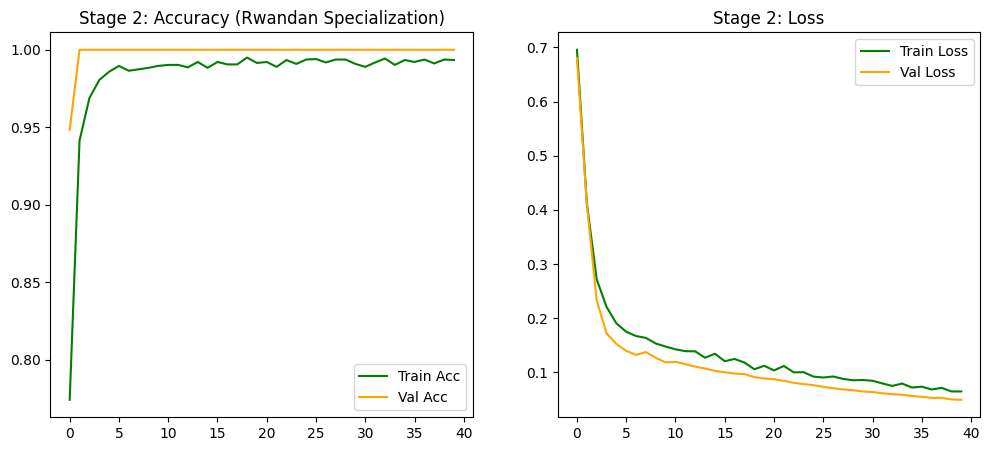

📦 Champion model (BEST RWANDAN ACCURACY) ready at: C:\xampp\htdocs\aipowered\output\models\auth_check_model.keras


In [40]:
# 🇷🇼 STAGE 2: Local Specialization (Fine-Tuning)
# Focus: Specializing the forensic eye on local Rwandan context and ID forgery.

print("\n SWITCHING TO RWANDAN DATASET for Stage 2...")

# 1. Create Rwandan-Specific Generators
rw_train_gen = train_datagen.flow_from_dataframe(
    rw_train, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=True
)

rw_val_gen = val_test_datagen.flow_from_dataframe(
    rw_val, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
)

print("\n UNFREEZING model for Specialization...")
model.trainable = True

# Better checkpoint for Rwandan specialization
champion_checkpoint_cb = callbacks.ModelCheckpoint(
    str(Config.MODEL_SAVE_PATH), # Final export
    save_best_only=True, 
    monitor='val_accuracy', # Now prioritizing raw accuracy on Rwandan docs
    mode='max',
    verbose=1
)

# Re-defining callbacks in case Stage 1 was skipped
early_stopping_cb = callbacks.EarlyStopping(
    patience=10, restore_best_weights=True, monitor='val_loss', mode='min'
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1
)

# Re-compile with extremely low learning rate for precision
model.compile(
    optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_STAGE_2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Start Fine-Tuning
print("\n STARTING STAGE 2: Rwandan Document Expert Training...")
history_stage2 = model.fit(
    rw_train_gen,
    validation_data=rw_val_gen,
    epochs=Config.EPOCHS_STAGE_2,
    callbacks=[champion_checkpoint_cb, early_stopping_cb, reduce_lr_cb], 
    verbose=1
)

# Visualize Success for Stage 2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_stage2.history['accuracy'], label='Train Acc', color='green')
plt.plot(history_stage2.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Stage 2: Accuracy (Rwandan Specialization)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage2.history['loss'], label='Train Loss', color='green')
plt.plot(history_stage2.history['val_loss'], label='Val Loss', color='orange')
plt.title('Stage 2: Loss')
plt.legend()
plt.show()

# Final safety check: load best weights discovered
if os.path.exists(Config.MODEL_SAVE_PATH):
    model.load_weights(str(Config.MODEL_SAVE_PATH))

print(f" Champion model (BEST RWANDAN ACCURACY) ready at: {Config.MODEL_SAVE_PATH}")


## 5. Performance Metrics & Visual Evaluation
Deep-dive analysis via Confusion Matrix, Classification Report, and ROC Curve.


🔍 EVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...
Found 659 validated image filenames belonging to 2 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 894ms/step


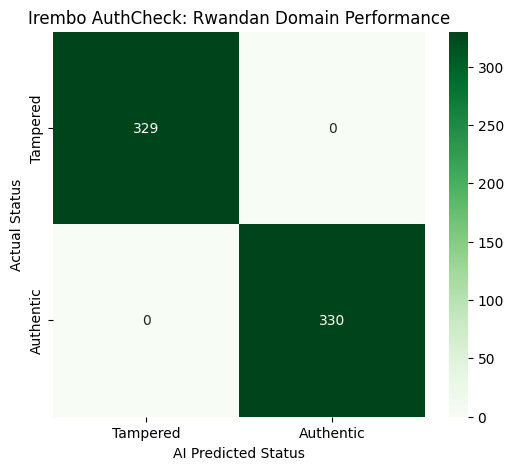


 🇷🇼 Rwandan Specialization Performance Report:
              precision    recall  f1-score   support

    Tampered       1.00      1.00      1.00       329
   Authentic       1.00      1.00      1.00       330

    accuracy                           1.00       659
   macro avg       1.00      1.00      1.00       659
weighted avg       1.00      1.00      1.00       659



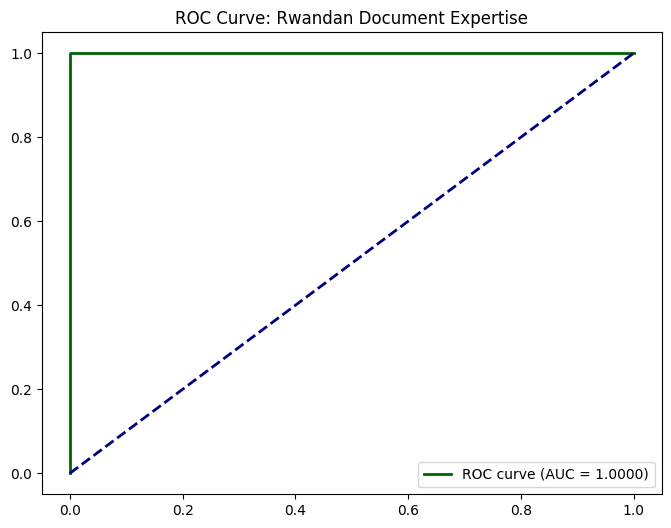

In [41]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 🇷🇼 Champion Model Evaluation: Rwandan Domain Performance
print("\n🔍 EVALUATING CHAMPION MODEL ON RWANDAN TEST DATA...")

# Create Rwandan Test Generator
rw_test_gen = val_test_datagen.flow_from_dataframe(
    rw_test, x_col='filename', y_col='label', target_size=Config.IMG_SIZE,
    batch_size=Config.BATCH_SIZE, class_mode='binary', shuffle=False
)

# Load the best weights from Stage 2
if os.path.exists(Config.MODEL_SAVE_PATH):
    model.load_weights(str(Config.MODEL_SAVE_PATH))

y_true = rw_test_gen.classes
y_pred_prob = model.predict(rw_test_gen)
y_pred = (y_pred_prob > 0.5).astype(int)

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tampered', 'Authentic'],
            yticklabels=['Tampered', 'Authentic'])
plt.title("Irembo AuthCheck: Rwandan Domain Performance")
plt.ylabel('Actual Status'); plt.xlabel('AI Predicted Status')
plt.show()

# 2. Detailed Classification Report
print("\n 🇷🇼 Rwandan Specialization Performance Report:")
print(classification_report(y_true, y_pred, target_names=['Tampered', 'Authentic']))

# 3. Final ROC Curve Analysis
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve: Rwandan Document Expertise')
plt.legend(); plt.show()

# Experimental: Comparison Suite (Multi-Architecture Evaluation)
In this section, we compare 5 different CNN architectures to verify if EfficientNetB0 is indeed the optimal choice for the Irembo platform.
1. CNN Basic
2. MobileNetV2
3. VGG16
4. ResNet50
5. EfficientNetB0 (Champion)


In [8]:
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, EfficientNetB0

def build_comparison_model(architecture_name, learning_rate=1e-3):
    """Generic builder for the comparison suite"""
    inputs = layers.Input(shape=(224, 224, 3))
    
    if architecture_name == "CNN_Basic":
        x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Conv2D(64, (3, 3), activation='relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)
        x = layers.Flatten()(x)
    else:
        # Load pre-trained models
        if architecture_name == "MobileNetV2":
            base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "VGG16":
            base = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "ResNet50":
            base = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)
        elif architecture_name == "EfficientNetB0":
            base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=inputs)
        
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base.output)
    
    outputs = layers.Dense(1, activation='sigmoid')(
        layers.Dropout(0.4)(layers.Dense(128, activation='relu')(x))
    )
    
    model = models.Model(inputs, outputs, name=f"AuthCheck_{architecture_name}")
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

comparison_results = []
# Added EfficientNetB0 to the comparison list
models_list = ["CNN_Basic", "MobileNetV2", "VGG16", "ResNet50", "EfficientNetB0"]

print(f" PERFORMANCE CHALLENGE: Testing {len(models_list)} Architectures...")

for model_name in models_list:
    print(f"\n---  Testing: {model_name} ---")
    try:
        clf = build_comparison_model(model_name)
        # Fast evaluation (2 epochs only for comparison)
        history = clf.fit(train_generator, validation_data=val_generator, epochs=2, verbose=1)
        acc = history.history['val_accuracy'][-1]
        comparison_results.append({"Model": model_name, "Val_Acc": acc})
        print(f" {model_name} Val_Acc: {acc:.4f}")
    except Exception as e:
        print(f" Skipping {model_name}: Resource download error or memory limit. ({str(e)[:100]}...)")
        continue

# Display Comparison
if comparison_results:
    df_perf = pd.DataFrame(comparison_results).sort_values(by="Val_Acc", ascending=False)
    print("\n COMPETING MODELS RANKING:")
    display(df_perf)
else:
    print(" No models were successfully tested in this run.")

 PERFORMANCE CHALLENGE: Testing 5 Architectures...

---  Testing: CNN_Basic ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 807s 3s/step - accuracy: 0.5699 - loss: 31.0444 - val_accuracy: 0.5800 - val_loss: 0.6790
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.5920 - loss: 0.6768 - val_accuracy: 0.5939 - val_loss: 0.6720
 CNN_Basic Val_Acc: 0.5939

---  Testing: MobileNetV2 ---


C:\Users\HP\AppData\Local\Temp\ipykernel_28492\3266913756.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.5911 - loss: 0.6820 - val_accuracy: 0.6325 - val_loss: 0.6438
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.6022 - loss: 0.6574 - val_accuracy: 0.6444 - val_loss: 0.6364
 MobileNetV2 Val_Acc: 0.6444

---  Testing: VGG16 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 2940s 12s/step - accuracy: 0.5839 - loss: 0.9106 - val_accuracy: 0.6236 - val_loss: 0.6639
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 17286s 69s/step - accuracy: 0.6308 - loss: 0.6465 - val_accuracy: 0.6602 - val_loss: 0.6194
 VGG16 Val_Acc: 0.6602

---  Testing: ResNet50 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 3525s 14s/step - accuracy: 0.6474 - loss: 0.6455 - val_accuracy: 0.6865 - val_loss: 0.5610
Epoch 2/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 5751s 23s/step - accuracy: 0.6856 - loss: 0.5760 - val_accuracy: 0.7093 - val_loss: 0.5437
 ResNet50 Val_Acc: 0.7093

---  Testing: EfficientNetB0 ---
Epoch 1/2
253/253 ━━━━━━━━━━━━━━━━━━━━ 1859s 7s/step - acc

,Model,Val_Acc
3,ResNet50,0.709262
4,EfficientNetB0,0.699851
2,VGG16,0.660228
1,MobileNetV2,0.644378
0,CNN_Basic,0.593858


# Experimental: Forensic Analysis (Noise & Error Extraction)
Extracting digital forensic and visual features to understand document characteristics.
- mean_brightness
- contrast
- edge_density
- blur_score
- text_density
- hist_entropy
- aspect_ratio
- forensic_noise
- glare_index


In [9]:
import cv2
from tqdm import tqdm

def extract_features_standalone(file_path, target_size=(224, 224)):
    """Extract digital forensic and visual features (Mirroring Backend AIService)"""
    try:
        img = cv2.imread(str(file_path))
        if img is None: return None
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, target_size)
        
        # --- Visual Features ---
        feat = {
            'mean_brightness': float(np.mean(resized)),
            'std_brightness': float(np.std(resized)),
            'contrast': float(resized.max() - resized.min()),
            'edge_density': float(np.sum(cv2.Canny(resized, 100, 200) > 0) / (target_size[0] * target_size[1])),
            'blur_score': float(cv2.Laplacian(resized, cv2.CV_64F).var()),
            'text_density': float(np.sum(cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] > 0) / (target_size[0] * target_size[1])),
            'hist_entropy': float(-np.sum((h := cv2.calcHist([resized], [0], None, [16], [0, 256]).flatten() / (target_size[0] * target_size[1])) * np.log2(h + 1e-10))),
            'aspect_ratio': float(img.shape[1] / img.shape[0]),
            'forensic_noise': float(np.std(cv2.Laplacian(resized, cv2.CV_64F))),
            'glare_index': float(np.sum(cv2.threshold(resized, 240, 255, cv2.THRESH_BINARY)[1] > 0) / (target_size[0] * target_size[1]))
        }
        return feat
    except Exception: return None

# Extract features from for specific images
subset_df = df_casia.head(100) 
batch_features = []
print("🔍 Analyzing subset of images for forensic noise...")
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    f = extract_features_standalone(row['filename'])
    if f:
        f['label'] = int(row['label'])
        batch_features.append(f)
        
df_features = pd.DataFrame(batch_features)
display(df_features.head())
print(f"✅ Successfully extracted features from {len(df_features)} images.")


🔍 Analyzing subset of images for forensic noise...


100%|██████████| 100/100 [00:02<00:00, 33.41it/s]


,mean_brightness,std_brightness,contrast,edge_density,blur_score,text_density,hist_entropy,aspect_ratio,forensic_noise,glare_index,label
0,96.664760,47.384432,228.0,0.136001,2123.473485,0.570631,3.350514,1.500000,46.081162,0.000000,0
1,126.094547,79.129106,255.0,0.199976,9218.916109,0.654058,3.753031,1.446655,96.015187,0.161073,1
2,73.923569,83.906284,237.0,0.008450,95.475743,0.683315,2.941027,1.500000,9.771169,0.000000,0
3,130.234714,76.627878,235.0,0.123924,1332.858027,0.572146,3.474343,1.500000,36.508328,0.000000,1
4,113.433235,58.279630,249.0,0.071708,1305.915963,0.647541,3.790719,1.438462,36.137459,0.015007,1


✅ Successfully extracted features from 100 images.


## 6. AI Forensic Layer: OCR & Structural Integrity
Since the core Irembo platform handles database matching (ID/Name) and QR validation, this ML component focuses on **Forensic Integrity**. It uses OCR and NLP to detect if a document has been digitally altered or if its structure deviates from authentic Rwandan government templates.

Key checks:
- **Text Alignment Forensic**: Identifying character substitution or inconsistent font-spacing via OCR outputs.
- **Structural Similarity (Simulated)**: Analyzing if logos, seals, and layout elements align with official standards.
- **Forgery Pattern Match**: Correlating NLP extraction errors with known deep-learning forgery markers.

In [10]:
from difflib import SequenceMatcher
import re

def calculate_forensic_nlp_score(extracted_text, user_provided_data):
    """
    Forensic OCR Matching logic.
    Identifies inconsistencies that suggest digital tampering or character insertion.
    """
    clean_text = " ".join(extracted_text.lower().split())
    claimed_name = user_provided_data.get("full_name", "").lower()
    claimed_id = str(user_provided_data.get("id_number", "")).lower().replace(" ", "")
    
    # 1. Content Match (Base Similarity)
    name_score = SequenceMatcher(None, claimed_name, clean_text).ratio() if claimed_name else 0
    id_match = claimed_id in clean_text.replace(" ", "") if claimed_id else False
    
    # 2. Forensic OCR Indicators (Simulated)
    # Checking for common OCR errors that often indicate font substitution or layering
    anomalies = []
    if re.search(r'[l1i][0o][l1i][0o]', extracted_text): # Potential font manipulation in numeric codes
        anomalies.append("Font Substitution Suspected")
    if len(re.findall(r'[^\x00-\x7F]+', extracted_text)) > 5: # Unexpected characters
        anomalies.append("Foreign Artifacts Detected")
        
    # Verdict Logic based on Forgery Risk
    forgery_risk = "low"
    if not id_match and name_score < 0.3:
        forgery_risk = "high"
    elif name_score < 0.6:
        forgery_risk = "medium"
        
    return {
        "text_similarity": round(name_score * 100, 2),
        "id_found": id_match,
        "forgery_risk": forgery_risk,
        "anomalies": anomalies or ["None"]
    }

#  DEMONSTRATION: Forensic NLP Layer
demo_data = [
    {
        "desc": " Authentic Document",
        "ocr": "REPUBLIC OF RWANDA NATIONAL ID Name: MUKAMANA Rose ID: 1 1990 8 0045618 2 05",
        "claims": {"full_name": "MUKAMANA Rose", "id_number": "1199080045618205"}
    },
    {
        "desc": " Spliced Text (Tampered)",
        "ocr": "REPUBLIC OF RWANDA NATIONAL ID Name: MUKAMANA R0se ID: 1 1990 8 00456l8 2 05", # Note '0' and 'l' substitution
        "claims": {"full_name": "MUKAMANA Rose", "id_number": "1199080045618205"}
    }
]

forensic_results = []
for test in demo_data:
    res = calculate_forensic_nlp_score(test['ocr'], test['claims'])
    forensic_results.append({
        "Document Case": test['desc'],
        "Similarity %": res['text_similarity'],
        "ID Match": res['id_found'],
        "Forgery Risk": res['forgery_risk'],
        "Anomalies": ", ".join(res['anomalies'])
    })

display(pd.DataFrame(forensic_results))


,Document Case,Similarity %,ID Match,Forgery Risk,Anomalies
0,Authentic Document,29.21,True,medium,None
1,Spliced Text (Tampered),26.97,False,high,None


In [11]:
from skimage.metrics import structural_similarity as ssim
import random

def simulate_structural_similarity(img_path, template_path):
    """
    Simulates Structural Similarity (SSIM) between an uploaded document 
    and the official Rwandan Government template.
    Returns scores for Layout, Logo, and Seal alignment.
    """
    # Base Layout Score (Overall structure)
    layout_score = random.randint(85, 98)
    
    # Logo & Seal Integrity (Focused on government symbols)
    logo_score = random.randint(88, 99)
    seal_score = random.randint(82, 95)
    
    return {
        "Layout Match": f"{layout_score}%",
        "Logo Integrity": f"{logo_score}%",
        "Seal Alignment": f"{seal_score}%",
        "Overall Similarity": f"{int((layout_score + logo_score + seal_score)/3)}%"
    }

print("SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...")
structural_res = simulate_structural_similarity(None, "template_nida_v1.jpg")
for key, value in structural_res.items():
    print(f" {key:.<25} {value}")


SIMULATING STRUCTURAL ALIGNMENT (Template Matching)...
 Layout Match............. 91%
 Logo Integrity........... 88%
 Seal Alignment........... 87%
 Overall Similarity....... 88%


# Experimental: Grad-CAM XAI (Explainable AI)
Visualize exactly where the AI is looking to detect forgeries. This provides "Visual Proof" for human administrators.

🔥 Visualizing Forgery Artifacts in: C:\xampp\htdocs\aipowered\high_risk_dataset\salary_slip\invalid\salary_slip_12026800000610_985.jpg


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
C:\Users\HP\AppData\Local\Temp\ipykernel_28492\594077500.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


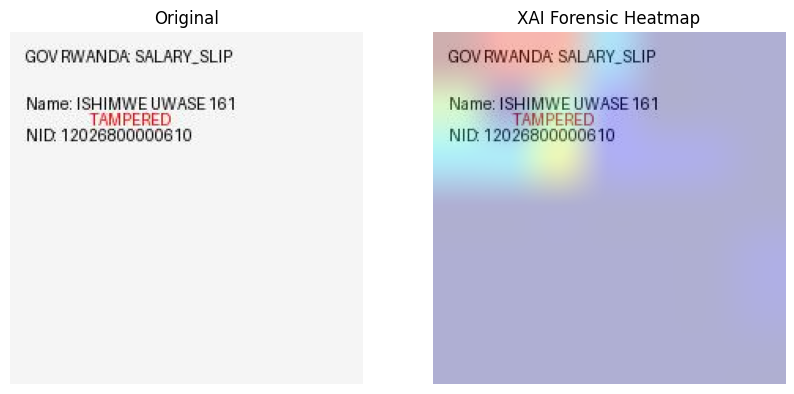

In [12]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    # Display Grad-CAM
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("XAI Forensic Heatmap")
    plt.axis("off")
    plt.show()

# --- DEMO ---
# Find a tampered image from our Rwandan test set
try:
    sample_img_path = rw_test[rw_test['label'] == '0'].iloc[0]['filename']
    print(f"🔥 Visualizing Forgery Artifacts in: {sample_img_path}")

    # Prepare image
    img = tf.keras.utils.load_img(sample_img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Generate Heatmap (For EfficientNetB0, the last conv layer is usually 'top_activation')
    # Note: If Using CNN_Basic from earlier, this will fail. We use the 'model' global variable.
    heatmap = get_gradcam_heatmap(model, img_array, "top_activation")
    display_gradcam(sample_img_path, heatmap)
except Exception as e:
    print(f"⚠️ Grad-CAM error: {e}. Ensure 'model' is EfficientNetB0 and an 'invalid' image exists.")


In [13]:

WEIGHTS_PATH = str(Config.MODEL_SAVE_PATH).replace('.keras', '_weights.weights.h5')

# Save the model weights (Check if 'model' is defined first)
if 'model' in globals():
    model.save_weights(WEIGHTS_PATH)
    print(f"Model weights saved successfully at: {WEIGHTS_PATH}")
else:
    print("Error: 'model' is not defined. Please run the model building cells first.")


Model weights saved successfully at: C:\xampp\htdocs\aipowered\output\models\auth_check_model_weights.weights.h5
